## Deskew the Data

We will look at two common approaches to deskewing data:

- the log transform
- scaling by the Box-Cox test

For purposes of comparison, we will keep both transforms.

We have previously looked at scaling data as a preprocessing step. Note that scaling of data will have no effect on its skewness. 

Another way we can verify this is via a test of skewness.

To perform this test we can use the `scipy.stats.skewtest`.

This function tests the null hypothesis that the skewness of the population that the sample was drawn from is the same as that of a corresponding normal distribution. Remember, a low p-value means reject the null hypothesis i.e the data is skewed!


In [1]:
import scipy.stats as st

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
from IPython.display import display

customers = pd.read_csv('Wholesale_customers_data.csv')
customers.Region = customers.Region.astype('category')
customers.Channel = customers.Channel.astype('category')
customer_features = customers.select_dtypes(exclude=['category'])

In [3]:
from sklearn.preprocessing import StandardScaler

In [4]:
scaler = StandardScaler()
customer_sc = scaler.fit_transform(customer_features)
customer_sc_df = pd.DataFrame(customer_sc, columns=customer_features.columns)

In [8]:
%whos DataFrame

Variable            Type         Data/Info
------------------------------------------
customer_features   DataFrame         Fresh   Milk  Grocer<...>n\n[440 rows x 6 columns]
customer_sc_df      DataFrame            Fresh      Milk  <...>n\n[440 rows x 6 columns]
customers           DataFrame        Channel Region  Fresh<...>n\n[440 rows x 8 columns]


In [6]:
%whos

Variable            Type              Data/Info
-----------------------------------------------
StandardScaler      type              <class 'sklearn.preproces<...>ng._data.StandardScaler'>
customer_features   DataFrame              Fresh   Milk  Grocer<...>n\n[440 rows x 6 columns]
customer_sc         ndarray           440x6: 2640 elems, type `float64`, 21120 bytes
customer_sc_df      DataFrame                 Fresh      Milk  <...>n\n[440 rows x 6 columns]
customers           DataFrame             Channel Region  Fresh<...>n\n[440 rows x 8 columns]
display             function          <function display at 0x10384e480>
np                  module            <module 'numpy' from '/op<...>kages/numpy/__init__.py'>
pd                  module            <module 'pandas' from '/o<...>ages/pandas/__init__.py'>
plt                 module            <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
scaler              StandardScaler    StandardScaler()
sns                 module        

In [9]:
del customers

In [10]:
%whos DataFrame

Variable            Type         Data/Info
------------------------------------------
customer_features   DataFrame         Fresh   Milk  Grocer<...>n\n[440 rows x 6 columns]
customer_sc_df      DataFrame            Fresh      Milk  <...>n\n[440 rows x 6 columns]


In [11]:
for col in customer_sc_df.columns:
    original_col_skewtest = st.skewtest(customer_features[col])
    scaled_col_skewtest = st.skewtest(customer_sc_df[col])
    print("{}\norig skew test: {} \nscaled skew test: {}\n\n".format(col, 
                                                                     original_col_skewtest,
                                                                     scaled_col_skewtest))

Fresh
orig skew test: SkewtestResult(statistic=np.float64(13.363200236723891), pvalue=np.float64(9.920555601203284e-41)) 
scaled skew test: SkewtestResult(statistic=np.float64(13.363200236723884), pvalue=np.float64(9.92055560120428e-41))


Milk
orig skew test: SkewtestResult(statistic=np.float64(16.59746336777718), pvalue=np.float64(7.269893932402766e-62)) 
scaled skew test: SkewtestResult(statistic=np.float64(16.597463367777177), pvalue=np.float64(7.269893932402974e-62))


Grocery
orig skew test: SkewtestResult(statistic=np.float64(15.727788993926845), pvalue=np.float64(9.755866710448696e-56)) 
scaled skew test: SkewtestResult(statistic=np.float64(15.727788993926845), pvalue=np.float64(9.755866710448696e-56))


Frozen
orig skew test: SkewtestResult(statistic=np.float64(19.301887122446967), pvalue=np.float64(5.178310882929005e-83)) 
scaled skew test: SkewtestResult(statistic=np.float64(19.301887122446967), pvalue=np.float64(5.178310882929005e-83))


Detergents_Paper
orig skew test: Ske

### Deskew by taking the log of the data

Many times the skew of data can be easily removed by taking the log of the data. Let's do so here.

We will then scale the data after deskewing.

In [15]:
np.log(1)

np.float64(0.0)

In [14]:
customer_log_df = np.log(1+customer_features)

In [16]:
scaler.fit(customer_log_df)
customer_log_sc = scaler.transform(customer_log_df)
customer_log_sc_df = pd.DataFrame(customer_log_sc, columns=customer_features.columns)

In [17]:
%whos DataFrame

Variable             Type         Data/Info
-------------------------------------------
customer_features    DataFrame         Fresh   Milk  Grocer<...>n\n[440 rows x 6 columns]
customer_log_df      DataFrame             Fresh      Milk <...>n\n[440 rows x 6 columns]
customer_log_sc_df   DataFrame            Fresh      Milk  <...>n\n[440 rows x 6 columns]
customer_sc_df       DataFrame            Fresh      Milk  <...>n\n[440 rows x 6 columns]


In [18]:
for col in customer_log_df.columns:
    original_col_skewtest = st.skewtest(customer_features[col])
    scaled_col_skewtest = st.skewtest(customer_sc_df[col])
    original_log_col_skewtest = st.skewtest(customer_log_df[col])
    scaled_log_col_skewtest = st.skewtest(customer_log_sc_df[col])
    print("""{}
    orig:       {} 
    scaled:     {}
    orig log:   {}
    scaled log: {}
    
    """.format(col, 
               original_col_skewtest,
               scaled_col_skewtest, 
               original_log_col_skewtest,
               scaled_log_col_skewtest))

Fresh
    orig:       SkewtestResult(statistic=np.float64(13.363200236723891), pvalue=np.float64(9.920555601203284e-41)) 
    scaled:     SkewtestResult(statistic=np.float64(13.363200236723884), pvalue=np.float64(9.92055560120428e-41))
    orig log:   SkewtestResult(statistic=np.float64(-10.10280950731593), pvalue=np.float64(5.368180213426713e-24))
    scaled log: SkewtestResult(statistic=np.float64(-10.10280950731593), pvalue=np.float64(5.368180213426713e-24))
    
    
Milk
    orig:       SkewtestResult(statistic=np.float64(16.59746336777718), pvalue=np.float64(7.269893932402766e-62)) 
    scaled:     SkewtestResult(statistic=np.float64(16.597463367777177), pvalue=np.float64(7.269893932402974e-62))
    orig log:   SkewtestResult(statistic=np.float64(-1.9212199962370617), pvalue=np.float64(0.054703978253562636))
    scaled log: SkewtestResult(statistic=np.float64(-1.9212199962370418), pvalue=np.float64(0.054703978253565155))
    
    
Grocery
    orig:       SkewtestResult(statistic=

/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_6525/3472150706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_features['Milk'], ax=ax[0,0])
/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_6525/3472150706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cus

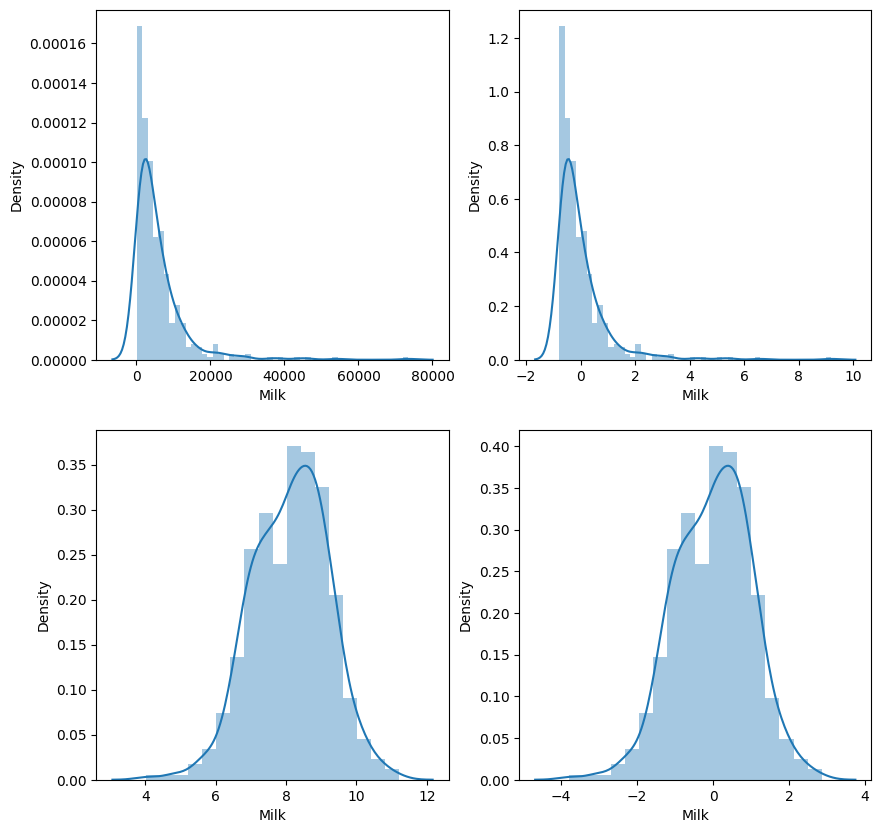

In [19]:
# plot milk for the four dataframes
fig, ax = plt.subplots(2,2, figsize=(10,10))
sns.distplot(customer_features['Milk'], ax=ax[0,0])
sns.distplot(customer_sc_df['Milk'], ax=ax[0,1])
sns.distplot(customer_log_df['Milk'], ax=ax[1,0])
sns.distplot(customer_log_sc_df['Milk'], ax=ax[1,1])
plt.show()


In [13]:
import warnings
warnings.simplefilter("ignore")

/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_6525/344446198.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_features[col], label=col)
/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_6525/344446198.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_

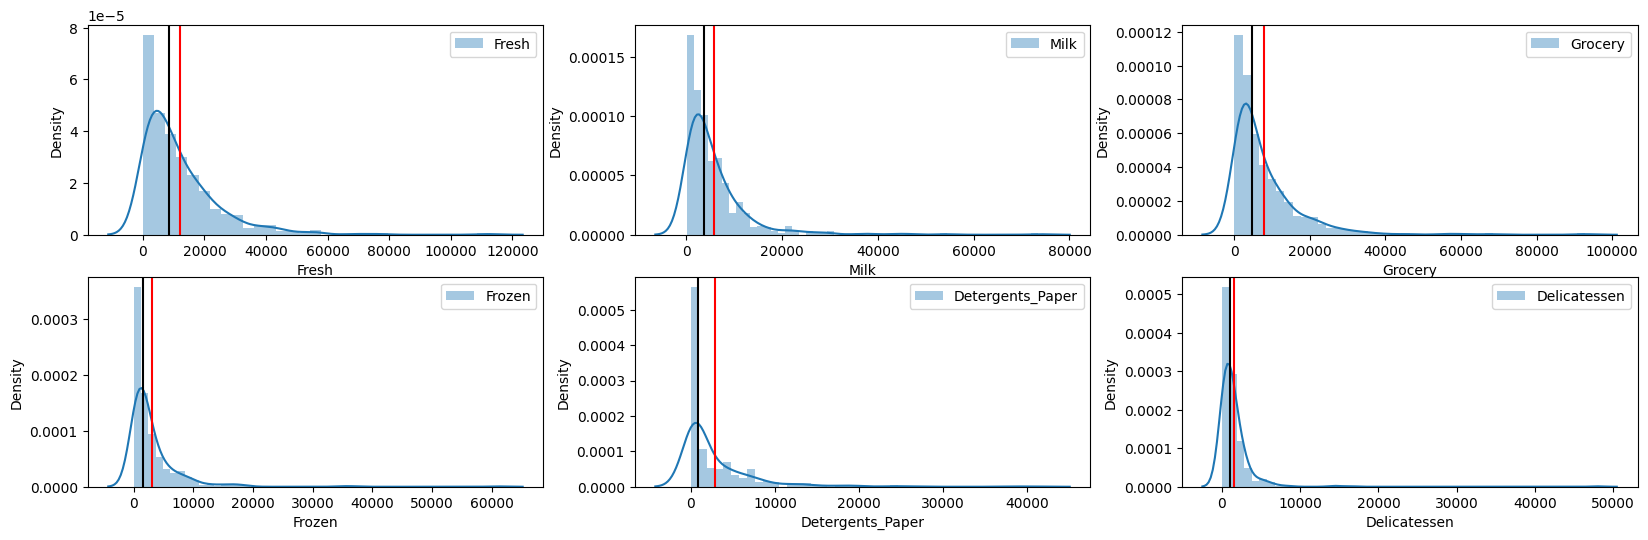

In [20]:
fig = plt.figure(figsize=(20,6))
for i, col in enumerate(customer_features.columns):
    fig.add_subplot(231+i)
    sns.distplot(customer_features[col], label=col)
    plt.axvline(customer_features[col].mean(), c='red')
    plt.axvline(customer_features[col].median(), c='black')
    plt.legend()

/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_6525/705769880.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_sc_df[col], label=col)
/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_6525/705769880.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_sc_

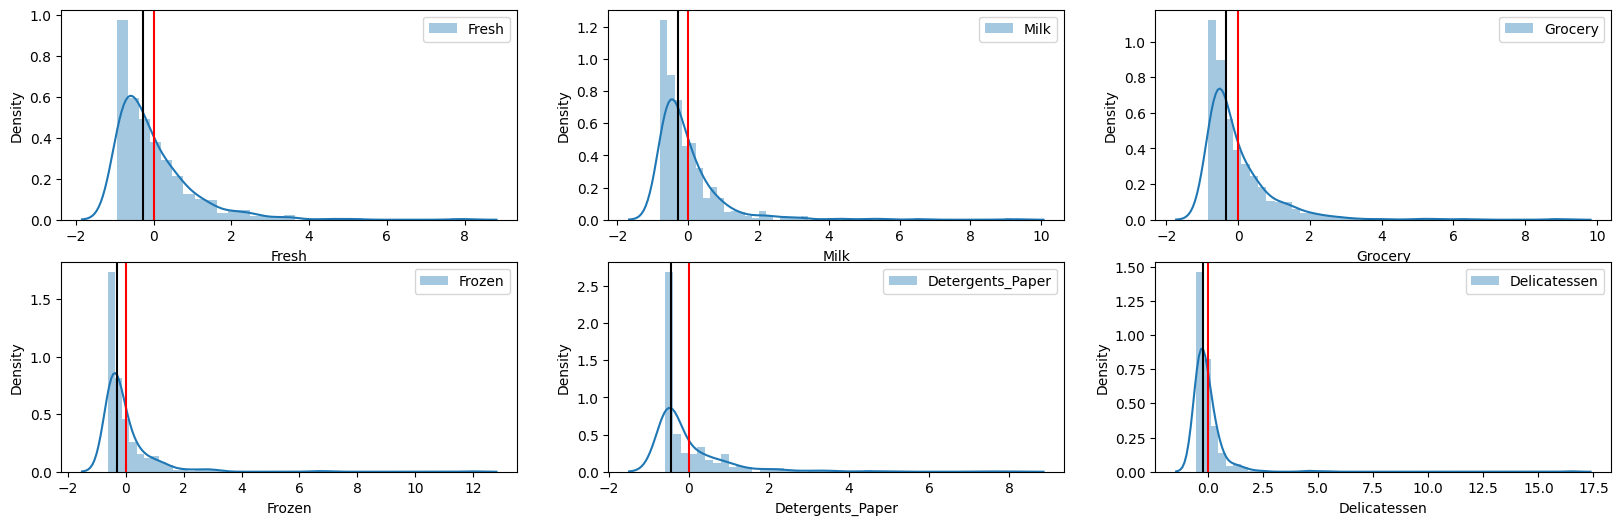

In [21]:
fig = plt.figure(figsize=(20,6))
for i, col in enumerate(customer_sc_df.columns):
    fig.add_subplot(231+i)
    sns.distplot(customer_sc_df[col], label=col)
    plt.axvline(customer_sc_df[col].mean(), c='red')
    plt.axvline(customer_sc_df[col].median(), c='black')
    plt.legend()

/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_6525/4157174740.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_log_sc_df[col], label=col)
/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_6525/4157174740.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(custom

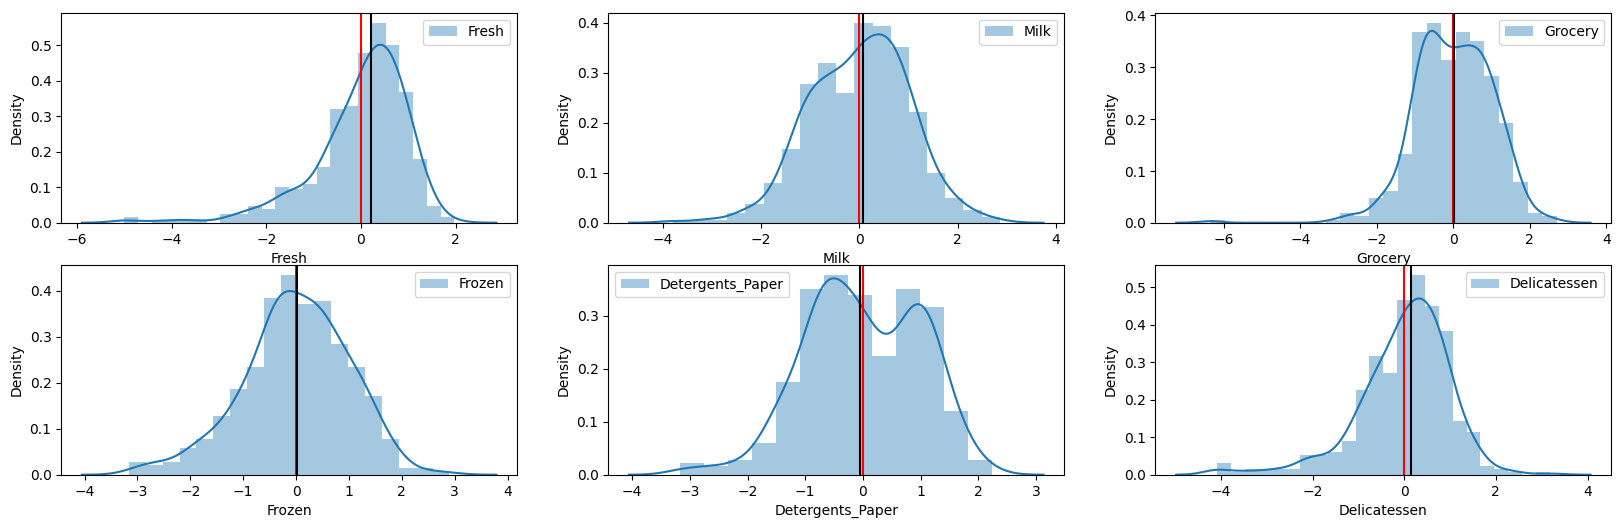

In [22]:
fig = plt.figure(figsize=(20,6))
for i, col in enumerate(customer_log_sc_df.columns):
    fig.add_subplot(231+i)
    sns.distplot(customer_log_sc_df[col], label=col)
    plt.axvline(customer_log_sc_df[col].mean(), c='red')
    plt.axvline(customer_log_sc_df[col].median(), c='black')
    plt.legend()

### Deskew by Box-Cox Test

The box cox test works by identifying the optimum power, $\lambda$ to raise the data where

$$\mathbf{x_i}' = \frac{\mathbf{x_i}^\lambda -1}{\lambda}$$

The implementation in Python is

```
y = (x**lmbda - 1) / lmbda, for lmbda > 0
    log(x),                 for lmbda = 0
```

`boxcox` requires the input data to be positive.

In [23]:
st

<module 'scipy.stats' from '/opt/miniconda3/envs/la-goose/lib/python3.12/site-packages/scipy/stats/__init__.py'>

In [25]:
customer_box_cox_df = pd.DataFrame()
for col in customer_features.columns:
    transformed_data, optimal_lambda = st.boxcox(customer_features[col])
    box_cox_trans = transformed_data
    customer_box_cox_df[col] = pd.Series(box_cox_trans)

In [26]:
scaler.fit(customer_box_cox_df)
customer_box_cox_sc = scaler.transform(customer_box_cox_df)
customer_box_cox_sc_df = pd.DataFrame(customer_box_cox_sc, columns=customer_features.columns)

In [27]:
%whos DataFrame

Variable                 Type         Data/Info
-----------------------------------------------
customer_box_cox_df      DataFrame             Fresh       Milk<...>n\n[440 rows x 6 columns]
customer_box_cox_sc_df   DataFrame            Fresh      Milk  <...>n\n[440 rows x 6 columns]
customer_features        DataFrame         Fresh   Milk  Grocer<...>n\n[440 rows x 6 columns]
customer_log_df          DataFrame             Fresh      Milk <...>n\n[440 rows x 6 columns]
customer_log_sc_df       DataFrame            Fresh      Milk  <...>n\n[440 rows x 6 columns]
customer_sc_df           DataFrame            Fresh      Milk  <...>n\n[440 rows x 6 columns]


### Talking about Moments

- 0th moment: total distribution or the data itself
- 1st moment: mean
- 2nd moment: variance ~ standard deviation
- 3rd moment: skewness
- 4th moment: kurtos



In [31]:
for col in customer_log_df.columns:
    original_col_skewtest = st.skewtest(customer_features[col])
    scaled_col_skewtest = st.skewtest(customer_sc_df[col])
    original_log_col_skewtest = st.skewtest(customer_log_df[col])
    scaled_log_col_skewtest = st.skewtest(customer_log_sc_df[col])
    original_box_cox_col_skewtest = st.skewtest(customer_box_cox_df[col])
    scaled_box_cox_col_skewtest = st.skewtest(customer_box_cox_sc_df[col])
    print("""{}
    orig:           {} 
    scaled:         {}
    orig log:       {}
    scaled log:     {}
    orig box-cox:   {}
    scaled box-cox: {}
    
    """.format(col, 
               original_col_skewtest,
               scaled_col_skewtest, 
               original_log_col_skewtest,
               scaled_log_col_skewtest, 
               original_box_cox_col_skewtest,
               scaled_box_cox_col_skewtest))

Fresh
    orig:           SkewtestResult(statistic=np.float64(13.363200236723891), pvalue=np.float64(9.920555601203284e-41)) 
    scaled:         SkewtestResult(statistic=np.float64(13.363200236723884), pvalue=np.float64(9.92055560120428e-41))
    orig log:       SkewtestResult(statistic=np.float64(-10.10280950731593), pvalue=np.float64(5.368180213426713e-24))
    scaled log:     SkewtestResult(statistic=np.float64(-10.10280950731593), pvalue=np.float64(5.368180213426713e-24))
    orig box-cox:   SkewtestResult(statistic=np.float64(-0.359946433547702), pvalue=np.float64(0.7188871920794526))
    scaled box-cox: SkewtestResult(statistic=np.float64(-0.359946433547702), pvalue=np.float64(0.7188871920794526))
    
    
Milk
    orig:           SkewtestResult(statistic=np.float64(16.59746336777718), pvalue=np.float64(7.269893932402766e-62)) 
    scaled:         SkewtestResult(statistic=np.float64(16.597463367777177), pvalue=np.float64(7.269893932402974e-62))
    orig log:       SkewtestResul

In [34]:
bc_describe = customer_box_cox_sc_df.describe().T
bc_describe['skew'] = st.skew(customer_box_cox_sc_df)
bc_describe

,count,mean,std,min,25%,50%,75%,max,skew
Fresh,440.0,-3.633457e-17,1.001138,-2.607665,-0.704377,0.046069,0.707954,3.396854,-0.041372
Milk,440.0,-6.136505e-16,1.001138,-3.378869,-0.747969,0.033850,0.688055,3.147986,0.001497
Grocery,440.0,-5.490558e-16,1.001138,-4.444466,-0.742098,-0.047451,0.736029,3.284827,0.035362
Frozen,440.0,-2.180074e-16,1.001138,-2.750228,-0.585563,-0.034552,0.658844,3.412880,0.002958
Detergents_Paper,440.0,2.018587e-16,1.001138,-2.864860,-0.751089,-0.100105,0.860226,2.477645,-0.017247
Delicatessen,440.0,4.037175e-18,1.001138,-2.934233,-0.628196,0.048680,0.623509,4.996726,0.104450


/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_6525/4157174740.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_log_sc_df[col], label=col)
/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_6525/4157174740.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(custom

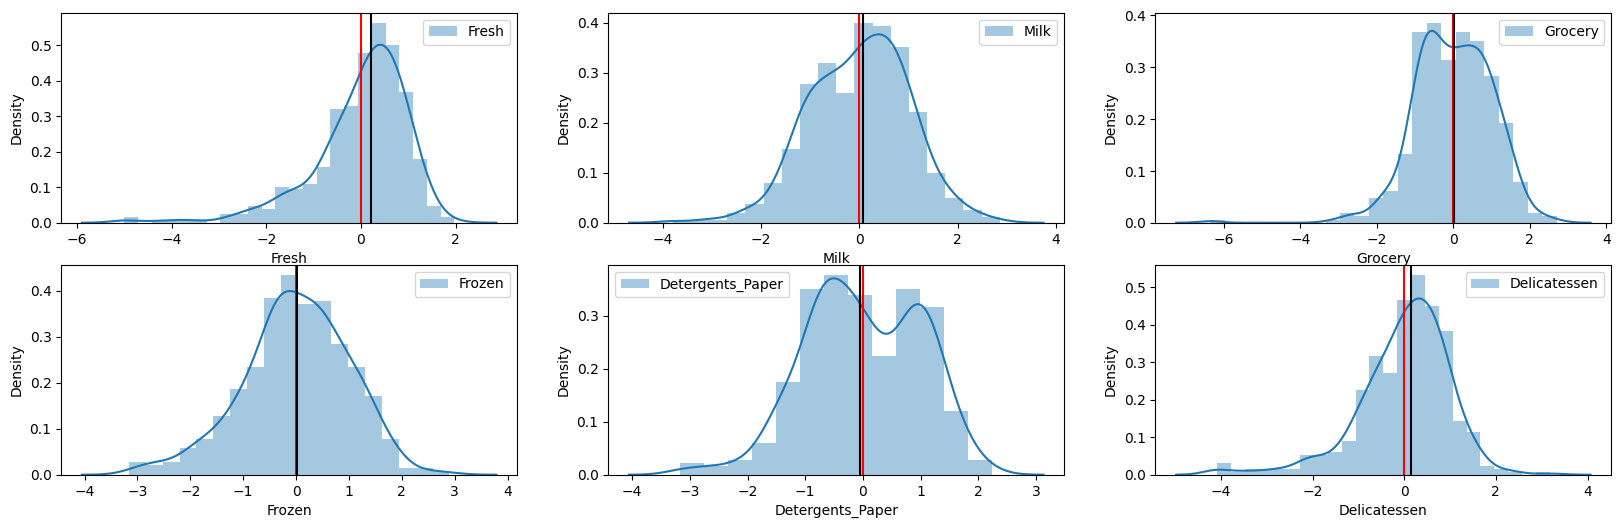

In [35]:
fig = plt.figure(figsize=(20,6))
for i, col in enumerate(customer_log_sc_df.columns):
    fig.add_subplot(231+i)
    sns.distplot(customer_log_sc_df[col], label=col)
    plt.axvline(customer_log_sc_df[col].mean(), c='red')
    plt.axvline(customer_log_sc_df[col].median(), c='black')
    plt.legend()

/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_6525/2770884932.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customer_box_cox_sc_df[col], label=col)
/var/folders/4_/5nh7mgns3q97l87bmzglq0wh0000gn/T/ipykernel_6525/2770884932.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cu

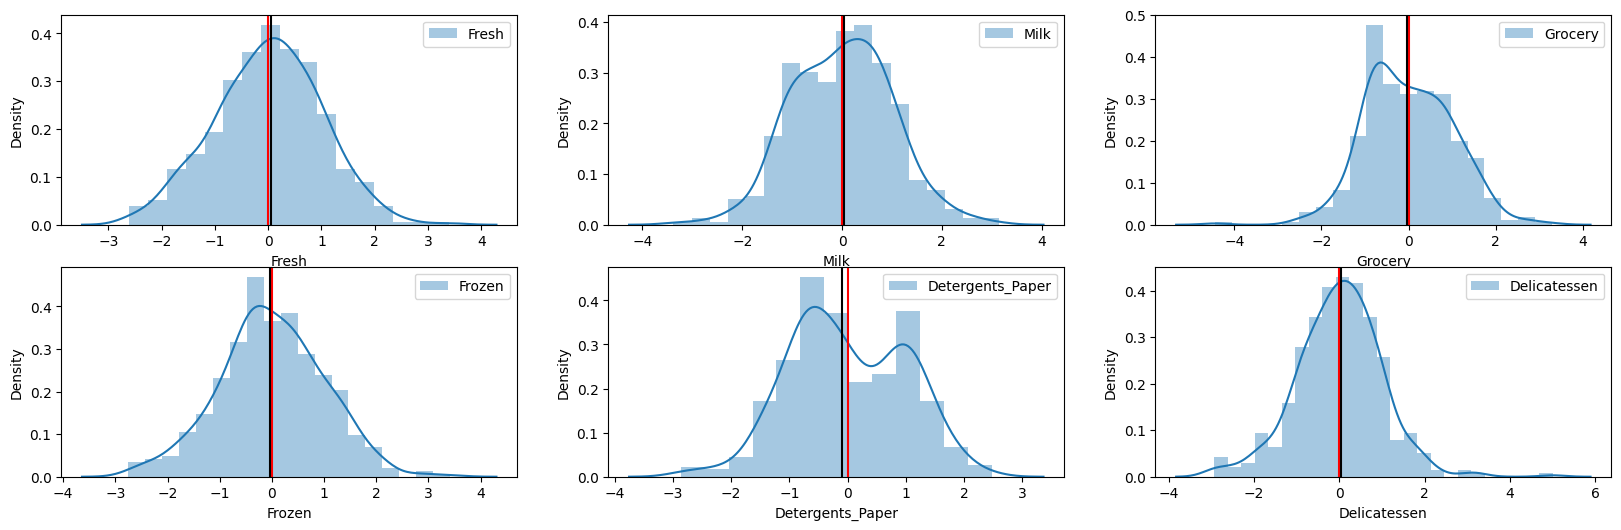

In [36]:
fig = plt.figure(figsize=(20,6))
for i, col in enumerate(customer_box_cox_sc_df.columns):
    fig.add_subplot(231+i)
    sns.distplot(customer_box_cox_sc_df[col], label=col)
    plt.axvline(customer_box_cox_sc_df[col].mean(), c='red')
    plt.axvline(customer_box_cox_sc_df[col].median(), c='black')
    plt.legend()

In [37]:
customers = pd.read_csv('Wholesale_customers_data.csv')

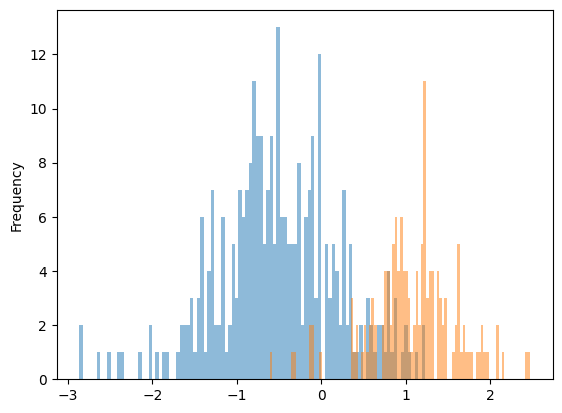

In [42]:
channel_1_filter = customers['Channel'] == 1
channel_2_filter = customers['Channel'] == 2
channel_1_dist = customer_box_cox_sc_df['Detergents_Paper'][channel_1_filter]
channel_2_dist = customer_box_cox_sc_df['Detergents_Paper'][channel_2_filter]

channel_1_dist.plot(kind="hist", bins=100, alpha=0.5)
channel_2_dist.plot(kind="hist", bins=100, alpha=0.5)
plt.show()



In [45]:
channel_1_filter

0      False
1      False
2      False
3       True
4      False
       ...  
435     True
436     True
437    False
438     True
439     True
Name: Channel, Length: 440, dtype: bool